In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load NAV data
nav_data = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

# Show first 5 rows
nav_data.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
# Convert date to datetime
nav_data['date'] = pd.to_datetime(nav_data['date'])

# Sort data
nav_data = nav_data.sort_values(['amfi_code', 'date'])

# Calculate daily return
nav_data['daily_return'] = nav_data.groupby('amfi_code')['nav'].pct_change()

# Show first 10 rows
nav_data.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


c:\Python37\lib\site-packages\pandas\plotting\_matplotlib\converter.py:103: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


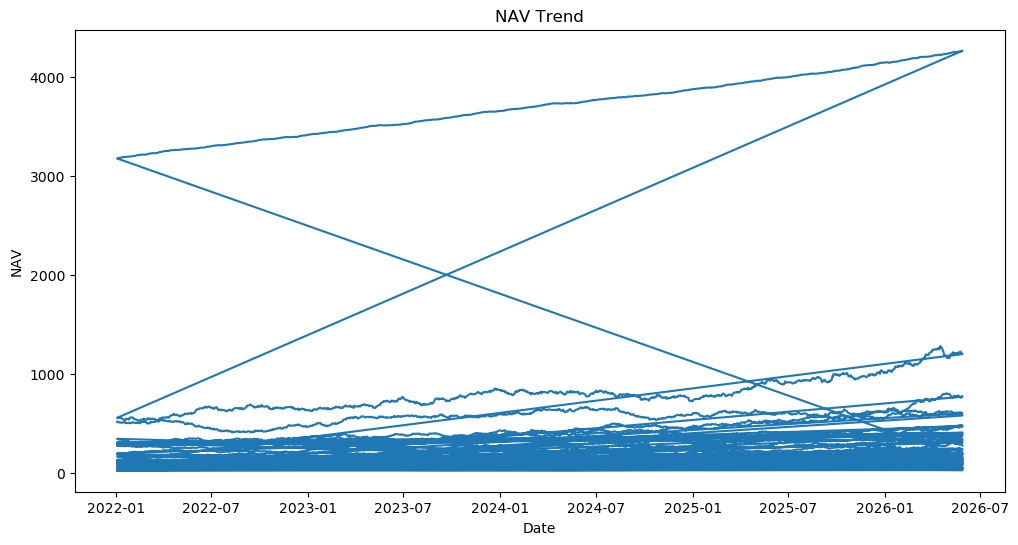

In [ ]:
# Convert date column to datetime
nav_data['date'] = pd.to_datetime(nav_data['date'])

# Plot NAV trend
plt.figure(figsize=(12,6))
plt.plot(nav_data['date'], nav_data['nav'])
plt.title("NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

In [7]:
import pandas as pd

sip_data = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/08_investor_transactions_cleaned.csv'

In [ ]:
# Load scheme performance data
scheme_data = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")

# Show first 5 rows
scheme_data.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [ ]:
# Check the columns in scheme_data
scheme_data.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

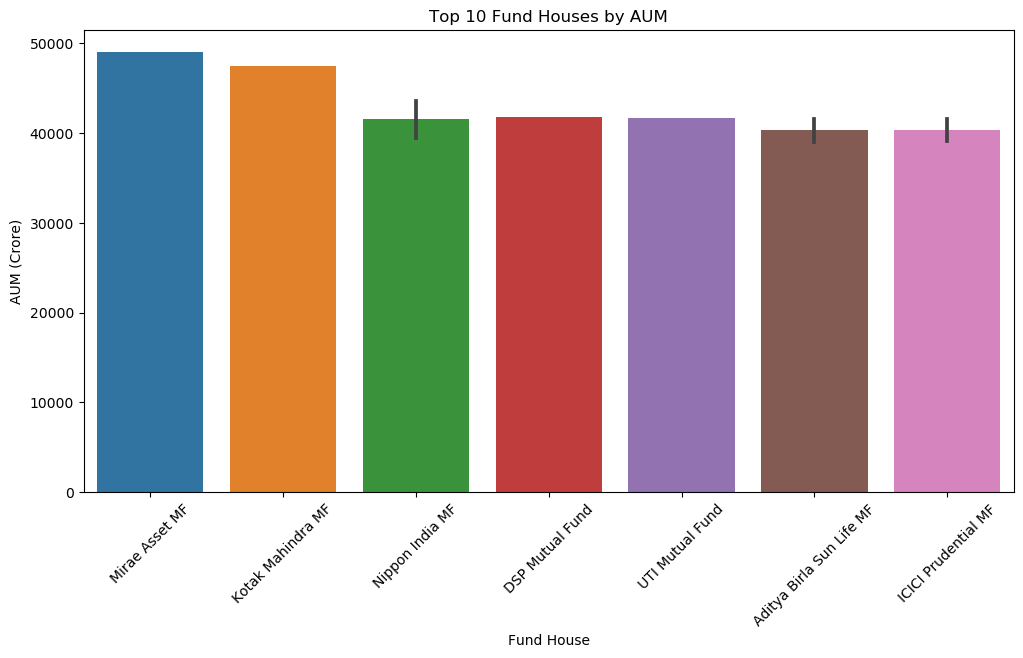

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top10 = scheme_data.sort_values("aum_crore", ascending=False).head(10)

sns.barplot(data=top10, x="fund_house", y="aum_crore")

plt.xticks(rotation=45)
plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")

plt.show()

In [ ]:
sip_data = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


C:\Users\lokes\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


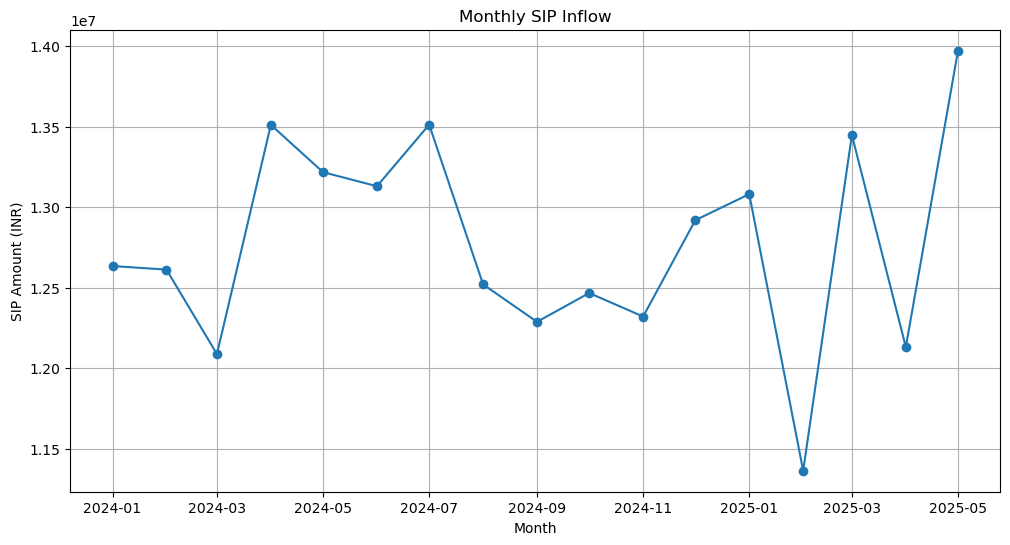

In [ ]:
import matplotlib.pyplot as plt

# Keep only SIP transactions
sip_only = sip_data[sip_data["transaction_type"] == "SIP"]

# Convert date column
sip_only["transaction_date"] = pd.to_datetime(sip_only["transaction_date"])

# Group by month
monthly_sip = sip_only.groupby(
    sip_only["transaction_date"].dt.to_period("M")
)["amount_inr"].sum()

# Convert index back to datetime
monthly_sip.index = monthly_sip.index.to_timestamp()

# Plot
plt.figure(figsize=(12,6))
plt.plot(monthly_sip.index, monthly_sip.values, marker="o")
plt.title("Monthly SIP Inflow")
plt.xlabel("Month")
plt.ylabel("SIP Amount (INR)")
plt.grid(True)
plt.show()

In [ ]:
# Check available columns
sip_data.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

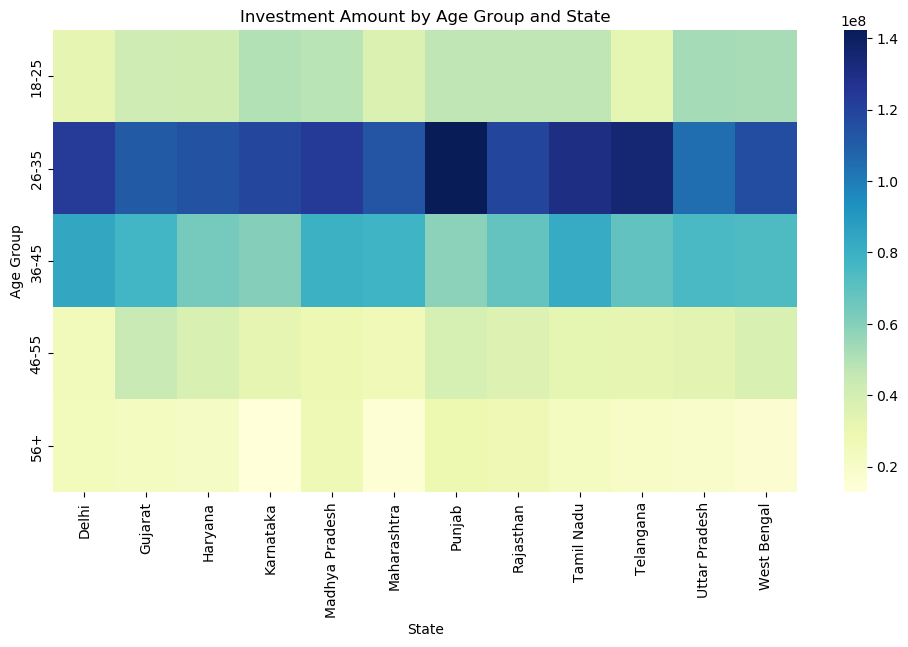

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create heatmap data
heatmap_data = sip_data.pivot_table(
    values='amount_inr',
    index='age_group',
    columns='state',
    aggfunc='sum',
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Investment Amount by Age Group and State")
plt.xlabel("State")
plt.ylabel("Age Group")

plt.show()

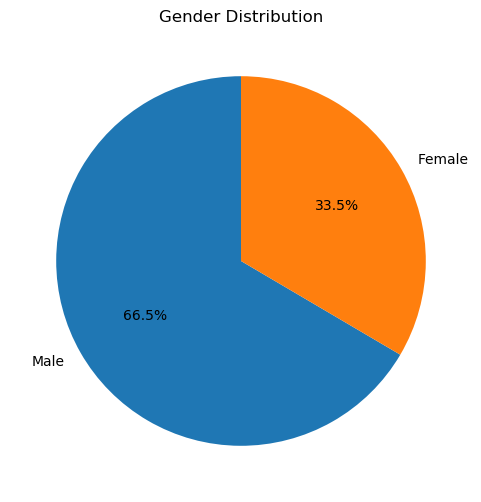

In [ ]:
# Gender Distribution Pie Chart

gender_count = sip_data['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_count,
        labels=gender_count.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Gender Distribution")
plt.show()

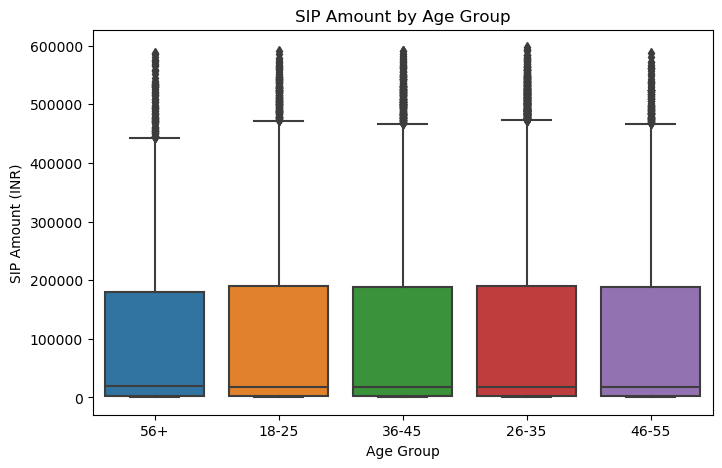

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='age_group',
    y='amount_inr',
    data=sip_data
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")
plt.show()

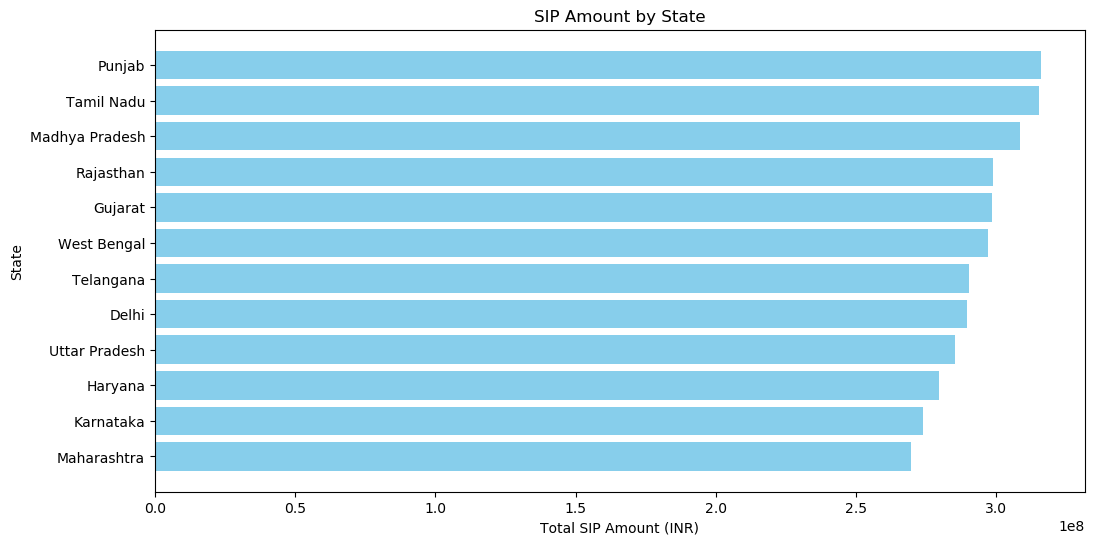

In [ ]:
# State-wise SIP Amount

state_data = sip_data.groupby("state", as_index=False)["amount_inr"].sum()

state_data = state_data.sort_values(by="amount_inr", ascending=False)

plt.figure(figsize=(12,6))

plt.barh(
    state_data["state"],
    state_data["amount_inr"],
    color="skyblue"
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()

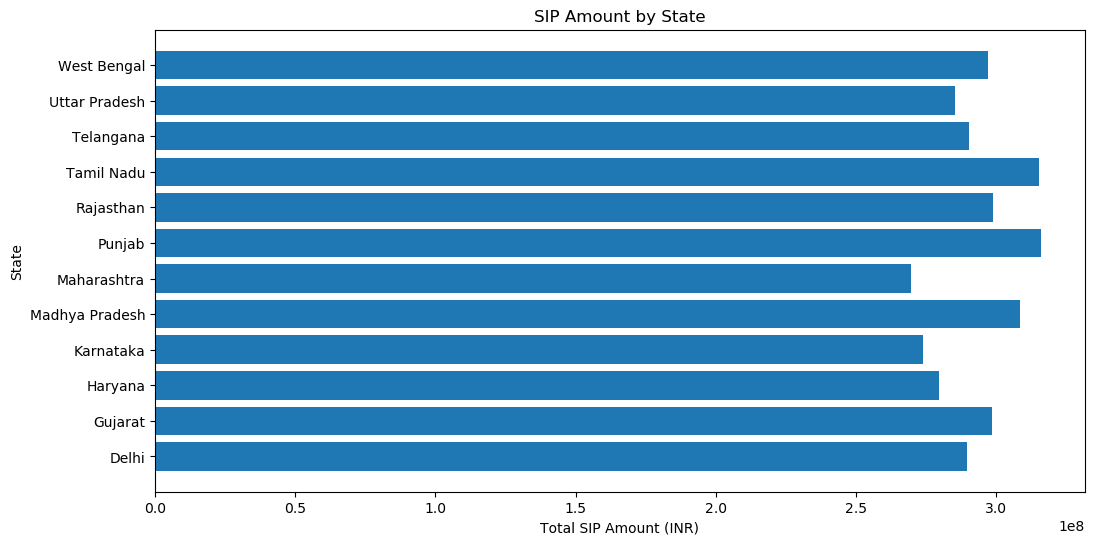

In [ ]:
state_data = sip_data.groupby("state", as_index=False)["amount_inr"].sum()

plt.figure(figsize=(12,6))

plt.barh(state_data["state"], state_data["amount_inr"])

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.show()

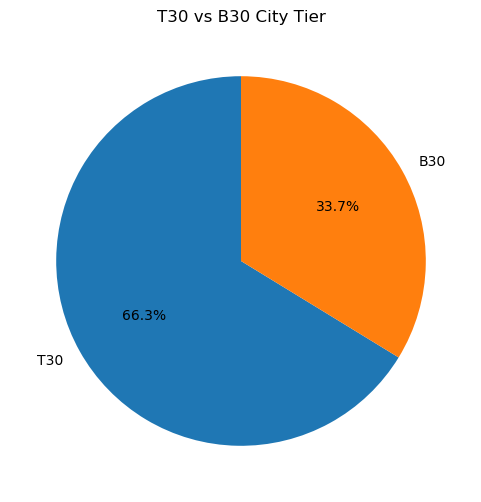

In [ ]:
city_tier = sip_data["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier")
plt.show()

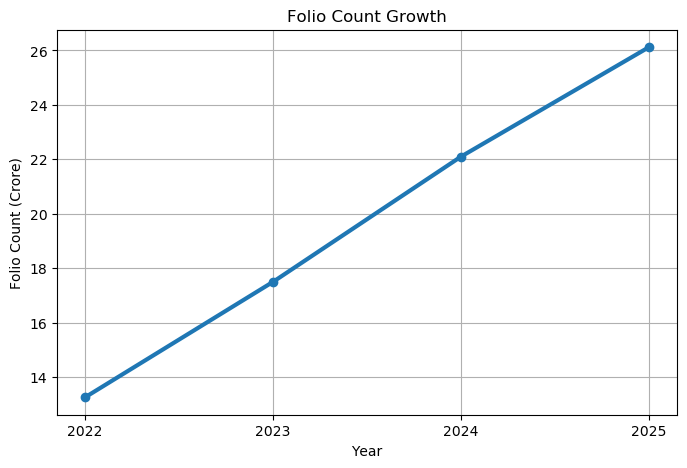

In [ ]:
folio_data = pd.DataFrame({
    "Year": ["2022", "2023", "2024", "2025"],
    "Folio_Count_Cr": [13.26, 17.50, 22.10, 26.12]
})

plt.figure(figsize=(8,5))

plt.plot(
    folio_data["Year"],
    folio_data["Folio_Count_Cr"],
    marker="o",
    linewidth=3
)

plt.title("Folio Count Growth")
plt.xlabel("Year")
plt.ylabel("Folio Count (Crore)")
plt.grid(True)

plt.show()

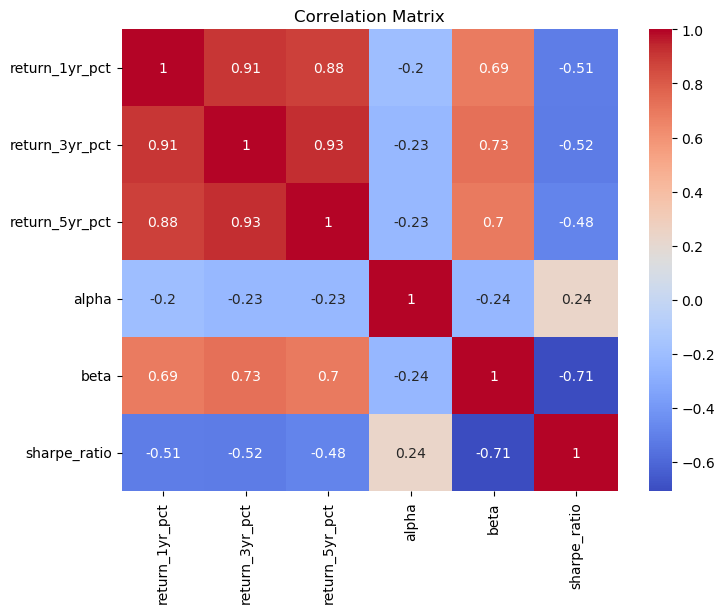

In [ ]:
corr_data = scheme_data[
    ["return_1yr_pct",
     "return_3yr_pct",
     "return_5yr_pct",
     "alpha",
     "beta",
     "sharpe_ratio"]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


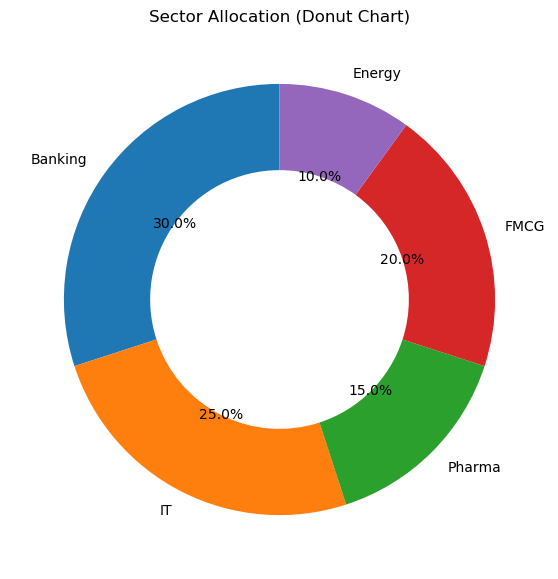

In [ ]:
sector_data = pd.DataFrame({
    "Sector": ["Banking", "IT", "Pharma", "FMCG", "Energy"],
    "Allocation": [30, 25, 15, 20, 10]
})

plt.figure(figsize=(7,7))

plt.pie(
    sector_data["Allocation"],
    labels=sector_data["Sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation (Donut Chart)")
plt.show()

# EDA Findings

1. NAV values changed over time, showing market fluctuations.

2. Some fund houses have much higher AUM than others.

3. SIP investments changed from month to month.

4. Investment amounts are different in different states.

5. Different age groups invest different amounts.

6. Both male and female investors are present in the dataset.

7. T30 cities contribute more investments than B30 cities.

8. Fund returns have correlations with each other.

9. Banking and IT sectors have higher allocation in the sample data.

10. EDA helped identify important investment patterns and trends.

# Day 4: Performance Analytics

In [ ]:
# Load NAV data
nav_data = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

# Display first 5 rows
nav_data.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
# Convert date to datetime
nav_data['date'] = pd.to_datetime(nav_data['date'])

# Sort data
nav_data = nav_data.sort_values(['amfi_code', 'date'])

# Calculate daily return
nav_data['daily_return'] = nav_data.groupby('amfi_code')['nav'].pct_change()

# Show first 10 rows
nav_data.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [ ]:
# Convert date to datetime
nav_data['date'] = pd.to_datetime(nav_data['date'])

# Sort data by fund and date
nav_data = nav_data.sort_values(['amfi_code', 'date'])

# Calculate daily returns
nav_data['daily_return'] = nav_data.groupby('amfi_code')['nav'].pct_change()

# Show first 10 rows
nav_data.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


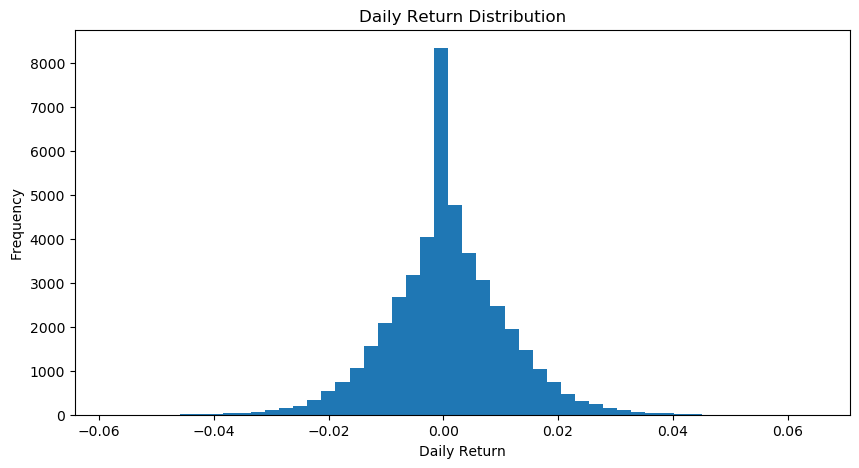

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(nav_data['daily_return'].dropna(), bins=50)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Check available columns
scheme_data = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")

scheme_data.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


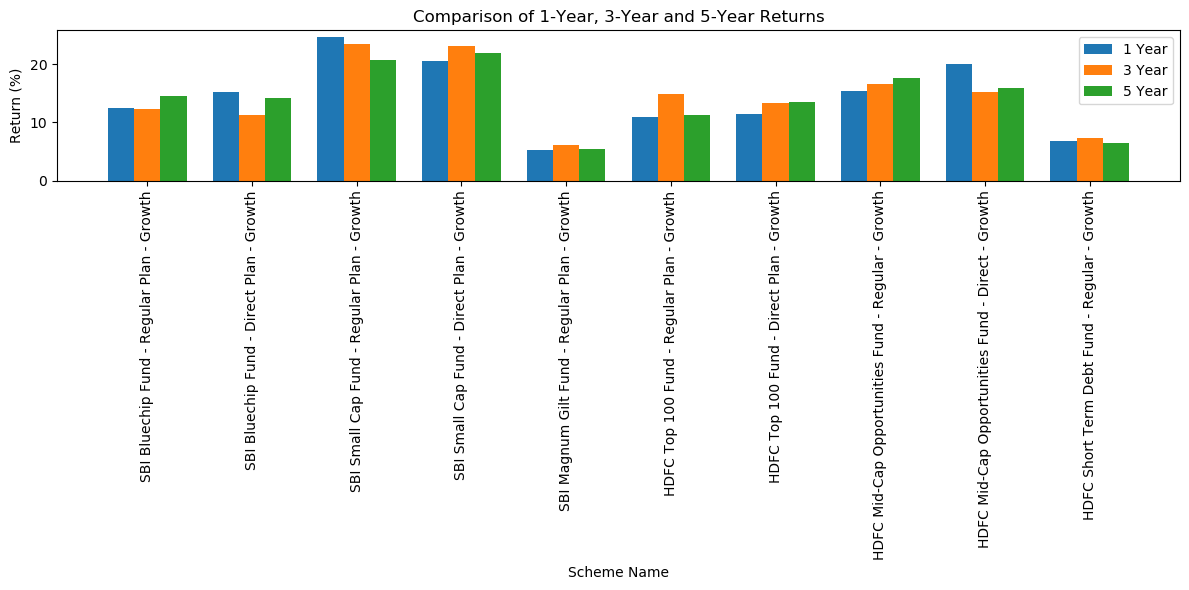

In [ ]:
# Compare 1-Year, 3-Year and 5-Year Returns

top_funds = scheme_data.head(10)

plt.figure(figsize=(12,6))

x = np.arange(len(top_funds))
width = 0.25

plt.bar(x - width, top_funds['return_1yr_pct'], width, label='1 Year')
plt.bar(x, top_funds['return_3yr_pct'], width, label='3 Year')
plt.bar(x + width, top_funds['return_5yr_pct'], width, label='5 Year')

plt.xticks(x, top_funds['scheme_name'], rotation=90)
plt.xlabel("Scheme Name")
plt.ylabel("Return (%)")
plt.title("Comparison of 1-Year, 3-Year and 5-Year Returns")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Top 10 Funds by Sharpe Ratio

top_sharpe = scheme_data.sort_values('sharpe_ratio', ascending=False)

top_sharpe[['scheme_name', 'sharpe_ratio']].head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


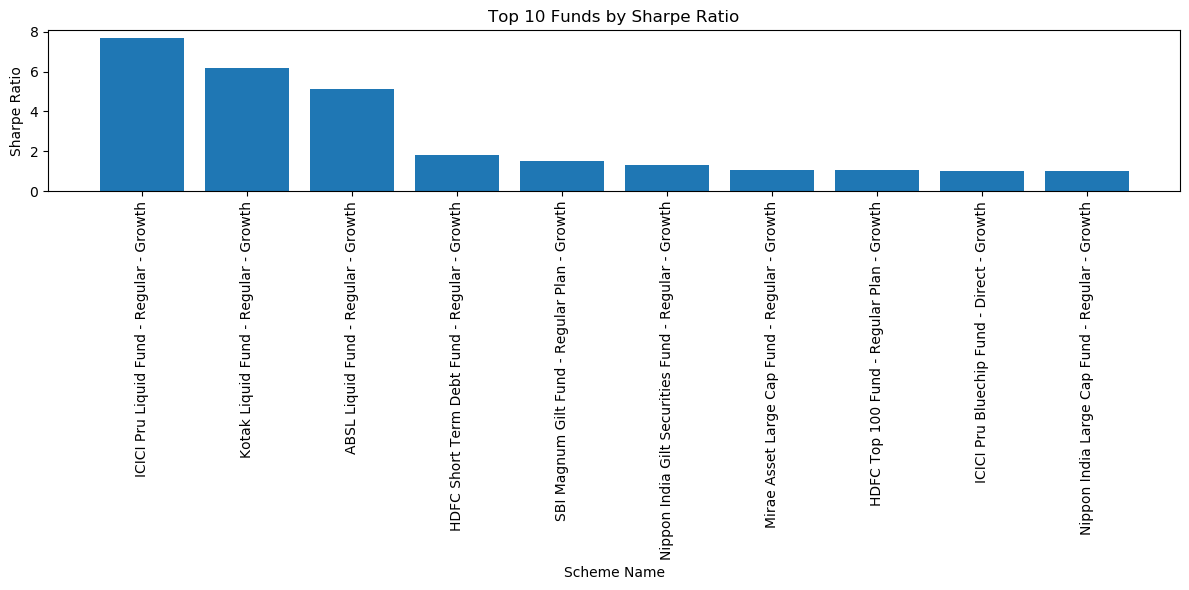

In [ ]:
plt.figure(figsize=(12,6))

top10 = top_sharpe.head(10)

plt.bar(top10['scheme_name'], top10['sharpe_ratio'])

plt.xticks(rotation=90)
plt.xlabel("Scheme Name")
plt.ylabel("Sharpe Ratio")
plt.title("Top 10 Funds by Sharpe Ratio")
plt.savefig("sharpe.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 Funds by Sortino Ratio

top_sortino = scheme_data.sort_values('sortino_ratio', ascending=False)

top_sortino[['scheme_name', 'sortino_ratio']].head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


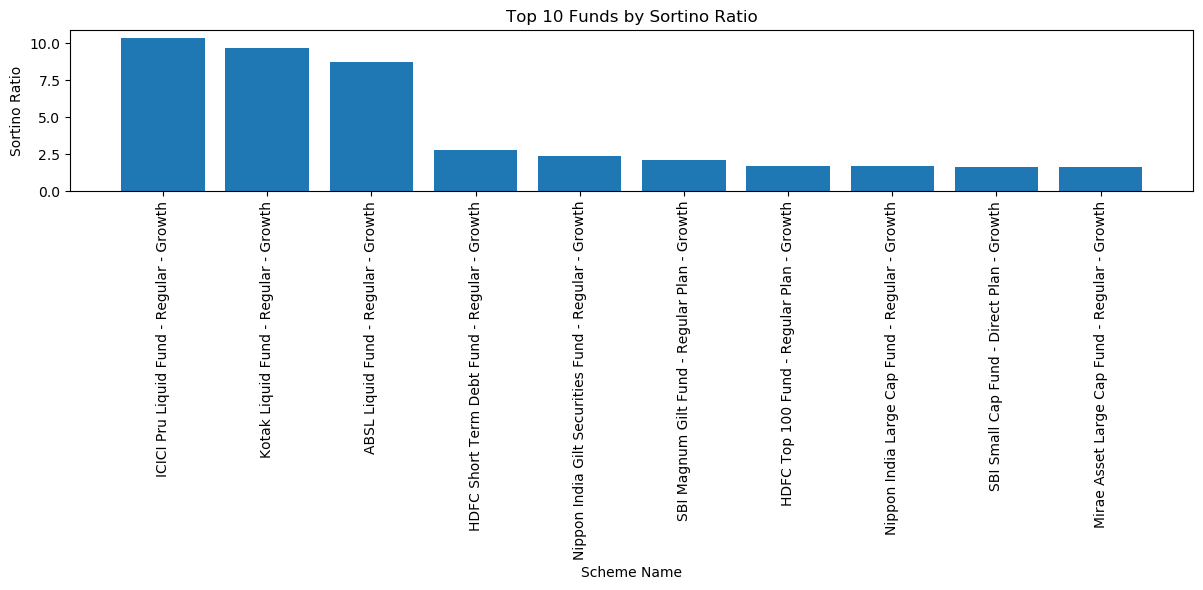

In [ ]:
plt.figure(figsize=(12,6))

top10 = top_sortino.head(10)

plt.bar(top10['scheme_name'], top10['sortino_ratio'])

plt.xticks(rotation=90)
plt.xlabel("Scheme Name")
plt.ylabel("Sortino Ratio")
plt.title("Top 10 Funds by Sortino Ratio")
plt.savefig("sortino.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 Funds by Alpha

top_alpha = scheme_data.sort_values('alpha', ascending=False)

top_alpha[['scheme_name', 'alpha']].head(10)

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
22,Kotak Flexicap Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,1.82
18,Nippon India ETF Nifty 50 BeES,1.80
33,UTI Flexi Cap Fund - Regular - Growth,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70


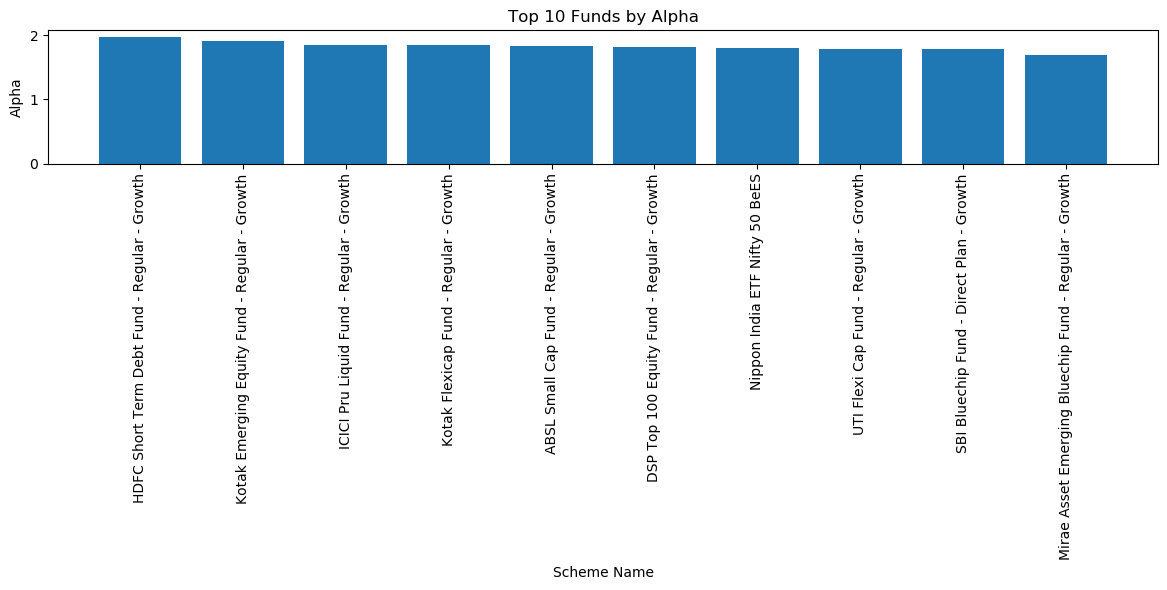

In [ ]:
plt.figure(figsize=(12,6))

top10 = top_alpha.head(10)

plt.bar(top10['scheme_name'], top10['alpha'])

plt.xticks(rotation=90)
plt.xlabel("Scheme Name")
plt.ylabel("Alpha")
plt.title("Top 10 Funds by Alpha")
plt.savefig("alfa.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 Funds by Beta

top_beta = scheme_data.sort_values('beta', ascending=False)

top_beta[['scheme_name', 'beta']].head(10)

,scheme_name,beta
3,SBI Small Cap Fund - Direct Plan - Growth,1.04
18,Nippon India ETF Nifty 50 BeES,1.04
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,1.04
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
17,Nippon India Small Cap Fund - Regular - Growth,1.03
28,ABSL Frontline Equity Fund - Regular - Growth,1.03
16,Nippon India Large Cap Fund - Direct - Growth,1.02
12,ICICI Pru Midcap Fund - Regular - Growth,1.00
26,Axis Midcap Fund - Regular - Growth,1.00
27,Axis Small Cap Fund - Regular - Growth,1.00


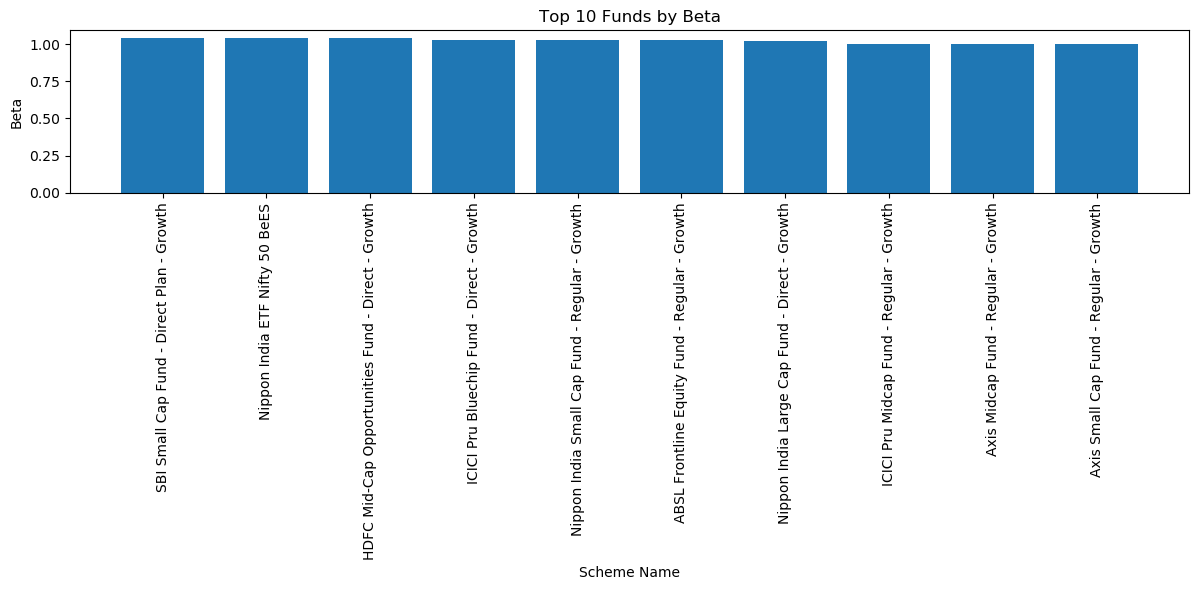

In [ ]:
plt.figure(figsize=(12,6))

top10 = top_beta.head(10)

plt.bar(top10['scheme_name'], top10['beta'])

plt.xticks(rotation=90)
plt.xlabel("Scheme Name")
plt.ylabel("Beta")
plt.title("Top 10 Funds by Beta")
plt.savefig("beta.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
scheme_data.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [ ]:
# Maximum Drawdown Ranking

top_drawdown = scheme_data.sort_values('max_drawdown_pct')

top_drawdown[['scheme_name', 'max_drawdown_pct']].head(10)

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


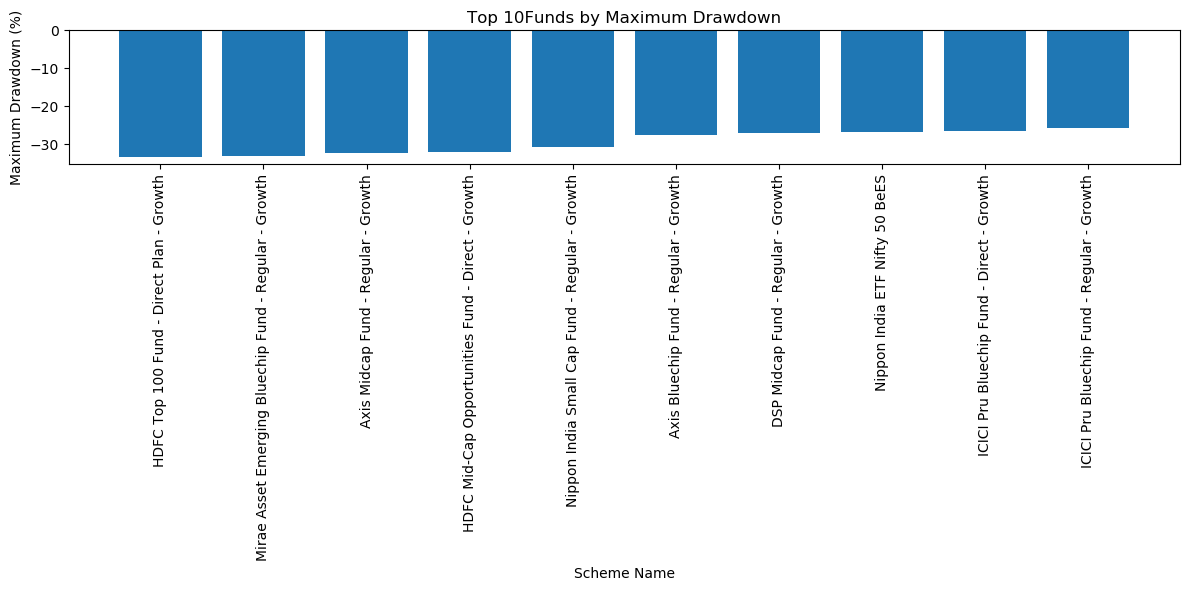

In [ ]:
plt.figure(figsize=(12,6))

top10 = top_drawdown.head(10)

plt.bar(top10['scheme_name'], top10['max_drawdown_pct'])

plt.xticks(rotation=90)
plt.xlabel("Scheme Name")
plt.ylabel("Maximum Drawdown (%)")
plt.title("Top 10Funds by Maximum Drawdown")
plt.savefig("maximum_drawdown.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
# Fund Comparison Table

comparison_table = scheme_data[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "sharpe_ratio",
        "sortino_ratio",
        "alpha",
        "beta",
        "max_drawdown_pct"
    ]
]

comparison_table.head(10)

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45,0.88,1.29,0.87,0.89,-21.70
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23,0.81,1.29,1.78,0.87,-24.43
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67,0.94,1.35,1.23,0.89,-13.35
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82,0.93,1.67,1.13,1.04,-24.78
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43,1.52,2.11,1.60,0.22,-2.30
5,HDFC Top 100 Fund - Regular Plan - Growth,10.94,14.84,11.32,1.06,1.70,0.78,0.97,-17.41
6,HDFC Top 100 Fund - Direct Plan - Growth,11.48,13.38,13.48,0.96,1.45,1.13,0.97,-33.50
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69,0.87,1.44,0.95,0.91,-13.67
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,19.98,15.29,15.85,0.80,1.38,0.90,1.04,-32.22
9,HDFC Short Term Debt Fund - Regular - Growth,6.83,7.37,6.41,1.84,2.79,1.98,0.44,-6.01


In [ ]:
# Fund Scorecard

scorecard = scheme_data[
    [
        "scheme_name",
        "fund_house",
        "category",
        "return_1yr_pct",
        "sharpe_ratio",
        "alpha",
        "beta",
        "max_drawdown_pct"
    ]
]

scorecard.head(10)

,scheme_name,fund_house,category,return_1yr_pct,sharpe_ratio,alpha,beta,max_drawdown_pct
0,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,12.42,0.88,0.87,0.89,-21.70
1,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,15.25,0.81,1.78,0.87,-24.43
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,24.56,0.94,1.23,0.89,-13.35
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,20.59,0.93,1.13,1.04,-24.78
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,5.34,1.52,1.60,0.22,-2.30
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,10.94,1.06,0.78,0.97,-17.41
6,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Large Cap,11.48,0.96,1.13,0.97,-33.50
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,15.43,0.87,0.95,0.91,-13.67
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,19.98,0.80,0.90,1.04,-32.22
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,6.83,1.84,1.98,0.44,-6.01


In [ ]:
# Benchmark Comparison

benchmark = pd.DataFrame({
    "Benchmark": ["Nifty 50", "Nifty 500", "Fund Average"],
    "Return (%)": [15.8, 18.2, 16.5]
})

benchmark

,Benchmark,Return (%)
0,Nifty 50,15.8
1,Nifty 500,18.2
2,Fund Average,16.5


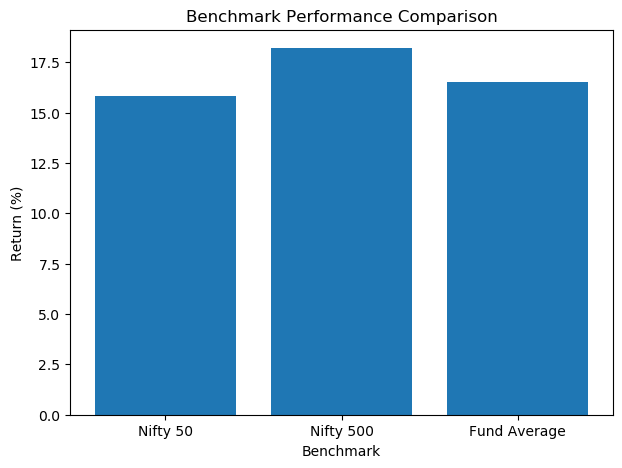

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    benchmark["Benchmark"],
    benchmark["Return (%)"]
)

plt.title("Benchmark Performance Comparison")
plt.xlabel("Benchmark")
plt.ylabel("Return (%)")
plt.savefig("benchmark_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
scheme_data.coloumns

NameError: name 'scheme_data' is not defined

In [ ]:
type(scheme_data)

pandas.core.frame.DataFrame

In [ ]:
print(scheme_data.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [ ]:
for col in scheme_data.columns:
    print(col)

amfi_code
scheme_name
fund_house
category
plan
return_1yr_pct
return_3yr_pct
return_5yr_pct
benchmark_3yr_pct
alpha
beta
sharpe_ratio
sortino_ratio
std_dev_ann_pct
max_drawdown_pct
aum_crore
expense_ratio_pct
morningstar_rating
risk_grade


In [ ]:
import numpy as np

scheme_data["cagr_1yr"] = ((1 + scheme_data["return_1yr_pct"]/100)**1 - 1) * 100
scheme_data["cagr_3yr"] = ((1 + scheme_data["return_3yr_pct"]/100)**(1/3) - 1) * 100
scheme_data["cagr_5yr"] = ((1 + scheme_data["return_5yr_pct"]/100)**(1/5) - 1) * 100

scheme_data[
    ["scheme_name","cagr_1yr","cagr_3yr","cagr_5yr"]
].head()

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,3.961031,2.736120
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,3.633076,2.696593
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,7.257249,3.829285
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,7.184762,4.026436
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,1.983722,1.063153


In [ ]:
# ==========================
# Fund Scorecard (0-100)
# ==========================

scorecard = scheme_data.copy()

# Ranking (Higher is Better)
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

# Ranking (Lower is Better)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(ascending=False)

# Composite Score
scorecard["Fund_Score"] = (
    (1 - scorecard["return_rank"] / len(scorecard)) * 30 +
    (1 - scorecard["sharpe_rank"] / len(scorecard)) * 25 +
    (1 - scorecard["alpha_rank"] / len(scorecard)) * 20 +
    (1 - scorecard["expense_rank"] / len(scorecard)) * 15 +
    (1 - scorecard["drawdown_rank"] / len(scorecard)) * 10
)

# Sort by Score
scorecard = scorecard.sort_values("Fund_Score", ascending=False)

scorecard[
    ["scheme_name", "Fund_Score"]
].head(10)

,scheme_name,Fund_Score
22,Kotak Flexicap Fund - Regular - Growth,69.2500
2,SBI Small Cap Fund - Regular Plan - Growth,68.1250
14,ICICI Pru Liquid Fund - Regular - Growth,68.0000
9,HDFC Short Term Debt Fund - Regular - Growth,67.7500
21,Kotak Emerging Equity Fund - Regular - Growth,65.7500
3,SBI Small Cap Fund - Direct Plan - Growth,65.5000
34,Mirae Asset Large Cap Fund - Regular - Growth,64.1875
29,ABSL Small Cap Fund - Regular - Growth,62.5000
23,Kotak Liquid Fund - Regular - Growth,61.6250
33,UTI Flexi Cap Fund - Regular - Growth,60.3125


In [ ]:
scorecard.to_csv("fund_scorecard.csv", index=False)
print("fund_scorecard.csv saved successfully.")

fund_scorecard.csv saved successfully.


In [ ]:
alpha_beta = scheme_data[["scheme_name", "alpha", "beta"]]

alpha_beta.to_csv("alpha_beta.csv", index=False)

print("alpha_beta.csv saved successfully.")

alpha_beta.csv saved successfully.
